# Prep data

We use the bike rental dataset used in https://christophm.github.io/interpretable-ml-book/data.html coming from https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset.

In [1]:
import zipfile
import pandas as pd

zip_path = "your_file.zip"
extract_to = "output_folder"

with zipfile.ZipFile("data/bike_sharing_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

df_day = pd.read_csv("data/day.csv")

# add counts two days prior
l = df_day["cnt"].tolist()[0:(len(df_day)-2)]
df_day["cnt_2d_bfr"] = list([0,0]) + l

# remove 0 humidity and missing counts
i = df_day[df_day.hum == 0].index
df_day.drop([0,1,i[0]], axis=0, inplace=True)
df_day.reset_index(inplace=True)

df_day.head()

,index,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,cnt_2d_bfr
0,2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,985
1,3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,801
2,4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,1349
3,5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606,1562
4,6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510,1600


In [2]:
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       728 non-null    int64  
 1   instant     728 non-null    int64  
 2   dteday      728 non-null    str    
 3   season      728 non-null    int64  
 4   yr          728 non-null    int64  
 5   mnth        728 non-null    int64  
 6   holiday     728 non-null    int64  
 7   weekday     728 non-null    int64  
 8   workingday  728 non-null    int64  
 9   weathersit  728 non-null    int64  
 10  temp        728 non-null    float64
 11  atemp       728 non-null    float64
 12  hum         728 non-null    float64
 13  windspeed   728 non-null    float64
 14  casual      728 non-null    int64  
 15  registered  728 non-null    int64  
 16  cnt         728 non-null    int64  
 17  cnt_2d_bfr  728 non-null    int64  
dtypes: float64(4), int64(13), str(1)
memory usage: 102.5 KB


In [3]:
df_day.describe()

,index,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,cnt_2d_bfr
count,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000,728.00000,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000,728.000000
mean,366.409341,367.409341,2.502747,0.502747,6.539835,0.028846,2.995879,0.68544,1.391484,0.495920,0.474794,0.628418,0.190350,850.973901,3668.627747,4519.601648,4513.765110
std,210.442823,210.442823,1.108920,0.500336,3.444359,0.167489,2.002401,0.46466,0.541823,0.183234,0.163150,0.140632,0.077574,686.605814,1551.317258,1926.503967,1935.465187
min,2.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000,22.000000
25%,184.750000,185.750000,2.000000,0.000000,4.000000,0.000000,1.000000,0.00000,1.000000,0.336458,0.337628,0.520000,0.134798,316.750000,2506.750000,3193.000000,3193.000000
50%,366.500000,367.500000,3.000000,1.000000,7.000000,0.000000,3.000000,1.00000,1.000000,0.501250,0.488627,0.626250,0.180971,722.000000,3669.500000,4551.000000,4551.000000
75%,548.250000,549.250000,3.000000,1.000000,10.000000,0.000000,5.000000,1.00000,2.000000,0.655833,0.609544,0.730104,0.233205,1097.750000,4792.750000,5978.500000,5978.500000
max,730.000000,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.00000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,8714.000000


# Train models

Similar to https://christophm.github.io/interpretable-ml-book/data.html we use 4 models to explore how the plots differ among modelling techniques:
1. Linear Regression
2. Random Forest
3. Support vector machine for regression (SVR)
4. Decision tree

Except from the train-test split being a 2:1 ratio and some performance metrics of the models, no modelling specifics are described. Below we use basic training for the models and achieve approximatly similar RMSE and MAE as presented by https://christophm.github.io/interpretable-ml-book/data.html. 

In [4]:
from sklearn.model_selection import train_test_split
features = ["season", "holiday", "workingday", "weathersit", "temp", "hum", "windspeed", "cnt_2d_bfr"]
target = "cnt"

X_train, X_test, y_train, y_test = train_test_split(df_day[features], 
                                                    df_day[target], test_size=0.33, random_state=42)

Especially, SVR is sensitive to differences in feature ranges, hence we scale the data. Note that this does reduce direct interpretability of the feature values and we have to correct for this later on.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import pandas as pd

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# linear model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn import linear_model

scores = dict()

mod_lin = linear_model.LinearRegression()
mod_lin.fit(X_train_scaled, y_train)
preds_lin = mod_lin.predict(X_test_scaled)


scores["linear regression"] = {"accuracy": mod_lin.score(X_test_scaled, y_test),
                               "RMSE": root_mean_squared_error(y_true=y_test, y_pred=preds_lin),
                               "MAE": mean_absolute_error(y_true=y_test, y_pred=preds_lin)}

In [7]:
# random forest
from sklearn.ensemble import RandomForestRegressor
mod_rf = RandomForestRegressor(max_depth=7, random_state=0)
mod_rf.fit(X_train_scaled, y_train)
preds_rf = mod_rf.predict(X_test_scaled)

scores["random forest"] = {"accuracy": mod_rf.score(X_test_scaled, y_test),
                               "RMSE": root_mean_squared_error(y_true=y_test, y_pred=preds_rf),
                               "MAE": mean_absolute_error(y_true=y_test, y_pred=preds_rf)}

In [8]:
# SVR
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 0.001, 0.01, 0.1, 1],
        'epsilon': [0.01, 0.1, 0.2, 0.5]
    }
]
mod_svr = SVR()

grid = GridSearchCV(
    mod_svr,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train_scaled, y_train)

from sklearn.svm import SVR
mod_svr.set_params(**grid.best_params_)
mod_svr.fit(X_train_scaled, y_train)

preds_svr = mod_svr.predict(X_test_scaled)

scores["SVR"] = {"accuracy": mod_svr.score(X_test_scaled, y_test),
                               "RMSE": root_mean_squared_error(y_true=y_test, y_pred=preds_svr),
                               "MAE": mean_absolute_error(y_true=y_test, y_pred=preds_svr)}


In [9]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
mod_dt = DecisionTreeRegressor(max_depth=5, random_state=0)
mod_dt.fit(X_train_scaled, y_train)

preds_dt = mod_dt.predict(X_test_scaled)

scores["decision tree"] = {"accuracy": mod_dt.score(X_test_scaled, y_test),
                               "RMSE": root_mean_squared_error(y_true=y_test, y_pred=preds_dt),
                               "MAE": mean_absolute_error(y_true=y_test, y_pred=preds_dt)}



Results are relatively similar to the ones provided by https://christophm.github.io/interpretable-ml-book/data.html. The SVR model yields tha highest accuracy and lowest RMSE and MAE. 

In [10]:
pd.DataFrame(scores).transpose().round(2)

,accuracy,RMSE,MAE
linear regression,0.77,932.48,710.39
random forest,0.81,832.59,615.44
SVR,0.85,755.83,567.29
decision tree,0.70,1054.56,804.61


# Ceteris Paribus Plot (CP)

Now we are going to explore the effect of changing a specific feature on the outcome. The most basic way to do this is by means of a Ceteris Paribus Plots (CP). A CP shows how the value of a specific instance changes when changing a specific feature while keeping all of the other features fixed.

In [11]:
mods = dict({
    "linear regression": mod_lin,
    "random forest": mod_rf,
    "svm": mod_svr,
    "decision tree": mod_dt
})

0.482917


Text(0.5, 1.0, 'Change in predicted count for instance 7 with changing humidity')

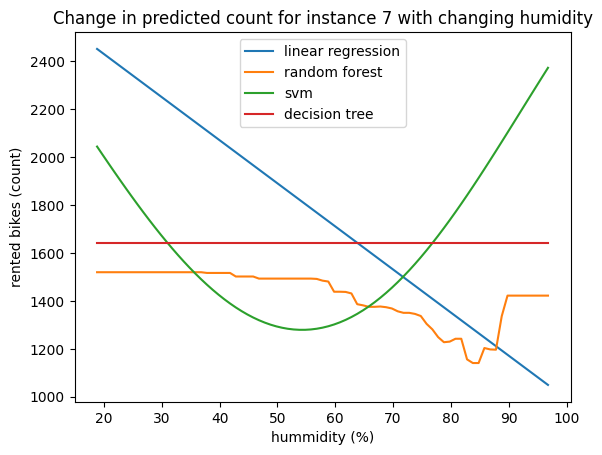

In [12]:
# select instance
from numpy import random
import numpy as np

# select an instance
instance = y_test.index[random.randint(0, len(y_test))]

# select orginial feature value
feature = "hum" # change to look at other features
feature_value = df_day.loc[instance, feature] 
print(feature_value)

# define feature range (in this case minimum to maximum humidity)
feature_range = np.arange(min(X_train.hum), max(X_train.hum), 0.01)

# create dataset and scale
row = X_test.loc[instance]
new_data = pd.DataFrame([row] * len(feature_range))
new_data['hum'] = feature_range
new_data_scaled = scaler.transform(new_data)

# predict over full range
import matplotlib.pyplot as plt
for mod in mods:
    preds = mods[mod].predict(new_data_scaled)
    plt.plot(feature_range*100, preds, label = mod)

# plot the cpb
plt.xlabel("hummidity (%)")
plt.ylabel("rented bikes (count)")
plt.legend()
plt.title("Change in predicted count for instance " + str(instance) + " with changing humidity")


# Individual Conditional Expectation (ICE)

Running the code above for the CP plot multiple times shows that changing the humidity can have a very different effect on the predicted number of rented bikes depending on the specific instance selected. We may be more interested in the general effect of change over all, or a susbset of instances. Below the Individual Conditional Expectation (ICE) plot is visualized, which is essentially the CP plot for every instance in one plot.

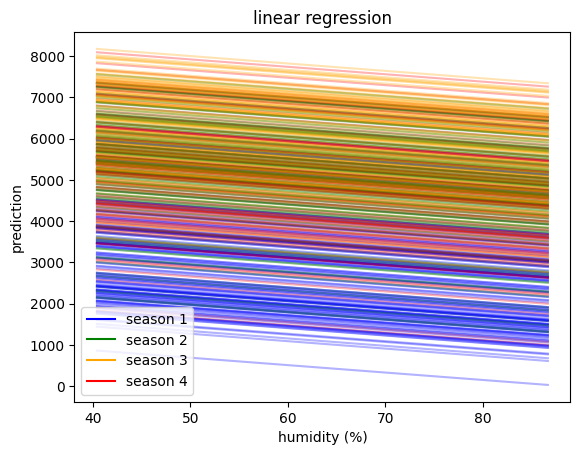

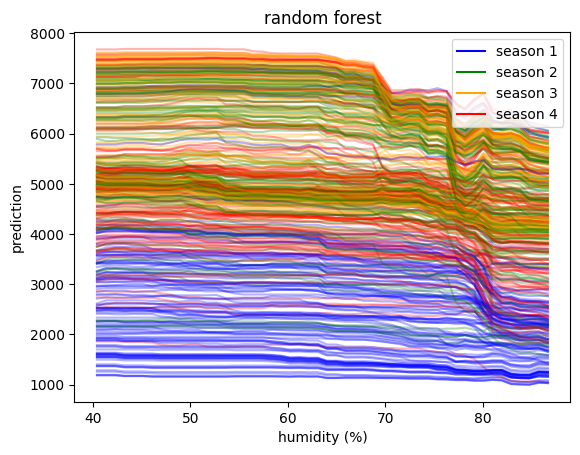

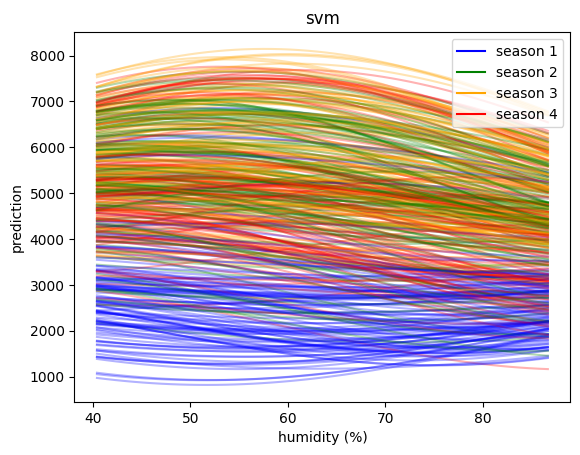

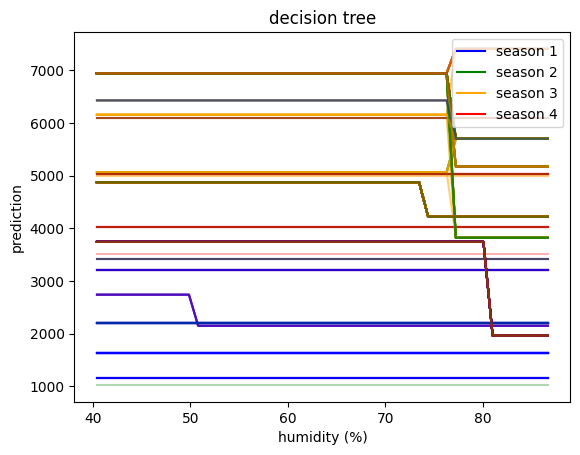

In [13]:
#ICE
from sklearn.pipeline import Pipeline
from sklearn.inspection import partial_dependence

feature = "hum"

season_colors = {
    1: "blue",
    2: "green",
    3: "orange",
    4: "red"
}


for mod in mods:

    pipe = Pipeline([
        ("scaler", scaler),   # we add the scaler to the pipeline so the PDP shows the unscaled values
        ("model", mods[mod])
    ])

    result = partial_dependence( # compute the CP lines for each instance
        pipe,
        X_train,
        features=[feature],
        kind="individual",
        grid_resolution=50
    )

    x = result["grid_values"][0]  # range for the feature
    ice = result["individual"][0] # individual line per instance

    import matplotlib.pyplot as plt

    for i, curve in enumerate(ice):
        s = X_train["season"].tolist()[i]
        plt.plot(x * 100, curve, color=season_colors[s], alpha=0.3)

    for s, color in season_colors.items():
        plt.plot([], [], color=color, label=f"season {s}")

    plt.title("Centered ICE (cICE)")
    plt.xlabel("humidity (%)")
    plt.ylabel("prediction")
    plt.title(mod)
    plt.legend()
    plt.show()



Now it is difficult to see the exact trend due to all instances starting at different values. By subtracting the original prediction we can center the plot around zero.

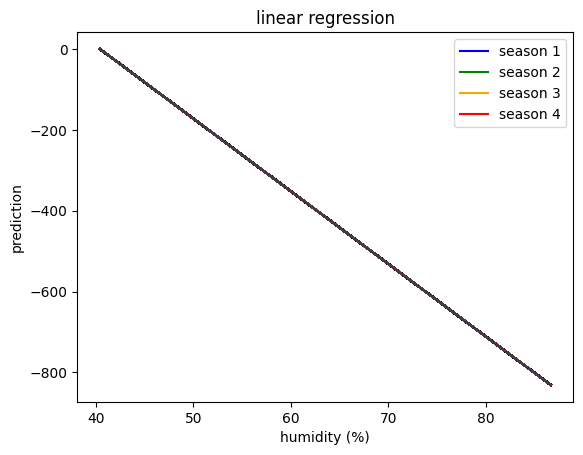

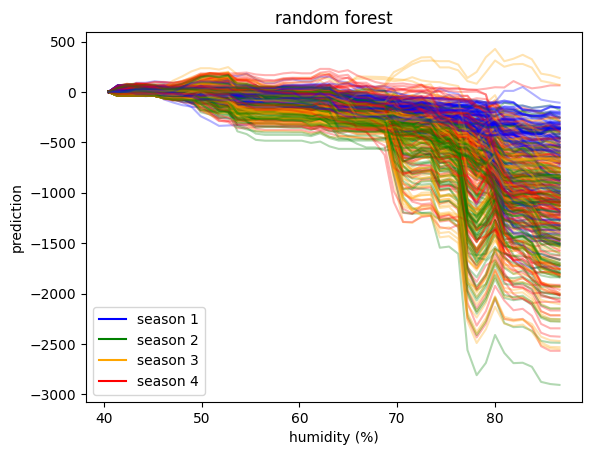

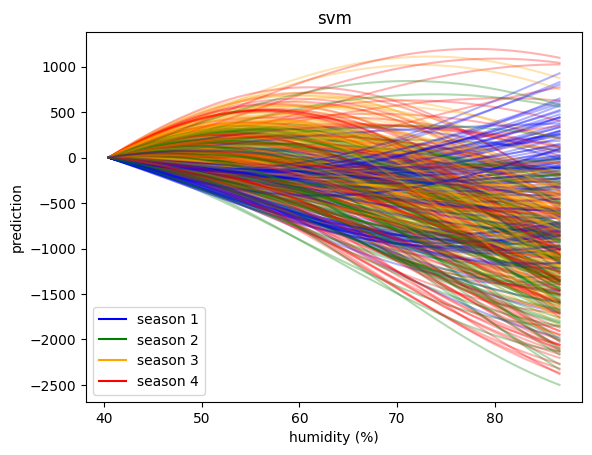

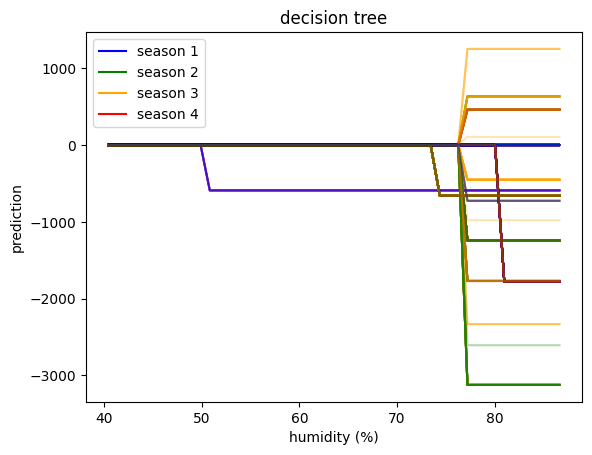

In [14]:
#ICE
from sklearn.pipeline import Pipeline
from sklearn.inspection import partial_dependence

feature = "hum"

season_colors = {
    1: "blue",
    2: "green",
    3: "orange",
    4: "red"
}


for mod in mods:

    pipe = Pipeline([
        ("scaler", scaler),   # we add the scaler to the pipeline so the PDP shows the unscaled values
        ("model", mods[mod])
    ])

    result = partial_dependence( # compute the CP lines for each instance
        pipe,
        X_train,
        features=[feature],
        kind="individual",
        grid_resolution=50
    )

    x = result["grid_values"][0]  # range for the feature
    ice = result["individual"][0] # individual line per instance

    ice_centered = ice - ice[:, [0]] # center values

    for i, curve in enumerate(ice_centered):
        s = X_train["season"].tolist()[i]
        plt.plot(x * 100, curve, color=season_colors[s], alpha=0.3)

    for s, color in season_colors.items():
        plt.plot([], [], color=color, label=f"season {s}")

    plt.title("Centered ICE (cICE)")
    plt.xlabel("humidity (%)")
    plt.ylabel("prediction")
    plt.title(mod)
    plt.legend()
    plt.show()



So what we see is that humidity actually relates to an increase in bike rentals in winter, but not in summer. We can also add another dimension. It is more difficult to inerpret a 3-D plot but sometimes you might want to see the interaction effect. Let's see what happens if we add temperature.

In [ ]:
# 3D ICE
from sklearn.inspection import PartialDependenceDisplay

features = [("hum", "temp")]

for mod in mods:
    pipe = Pipeline([
        ("scaler", scaler),   # we add the scaler to the pipeline so the PDP shows the unscaled values
        ("model", mods[mod])
    ])

    PartialDependenceDisplay.from_estimator(
        pipe,
        X_train,
        features=features,  # interaction
        kind="average"
    )

    plt.title(mod)

# LIME

After using CP, ICE, and PDP to analyze feature effects individually, we now want to better understand specific predictions by considering interactions between features. To do this, we train a local surrogate model using LIME, which approximates the model’s behavior in the vicinity of a single prediction.

In [ ]:
mods.keys()

dict_keys(['linear regression', 'random forest', 'svm', 'decision tree'])

svm


/Users/evakoenders/PythonProjects/Explainable_AI/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


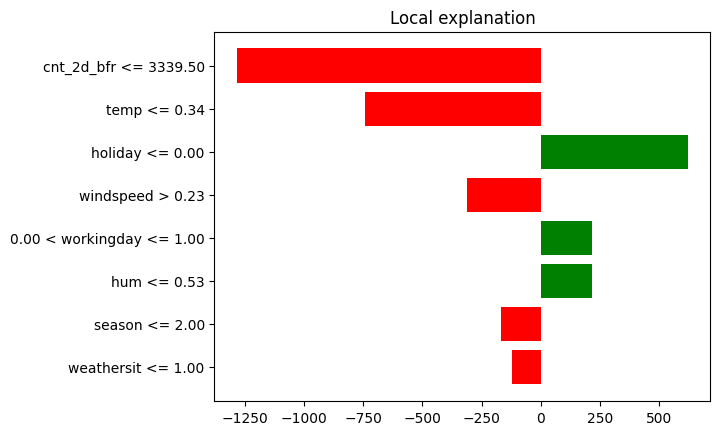

random forest


/Users/evakoenders/PythonProjects/Explainable_AI/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


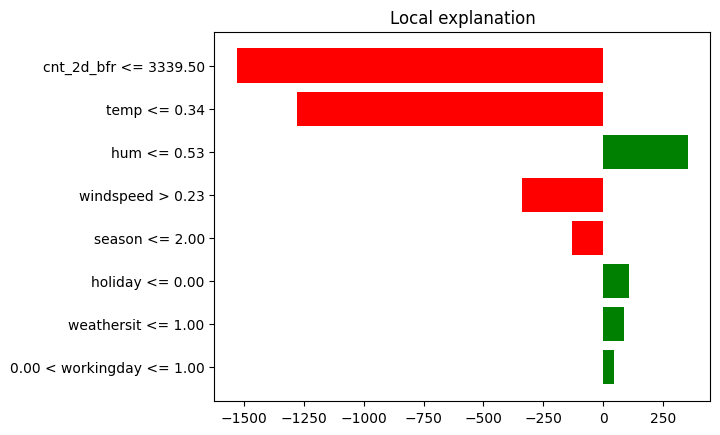

In [ ]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

i = 0     #choose instance of interest
instance = X_train.iloc[i]

for mod in ['svm', 'random forest']:
    # pipeline including model and scaling
    pipe = Pipeline([
        ("scaler", scaler),
        ("model", mods[mod])
    ])

    #create an explainer (we use regression in this case)
    explainer = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns.tolist(),
        mode="regression", #regression or classification
        discretize_continuous=True,
        kernel_width=3.0 #kernel width
    )

    #add predict function to pipe
    def predict_fn(x):
        x_df = pd.DataFrame(x, columns=X_train.columns)
        return pipe.predict(x_df)

    #explain the instance
    exp = explainer.explain_instance(
        data_row=instance.values,
        predict_fn=predict_fn,
        num_features=10 #max number of features to show in the explanation
    )

    # show explanation
    print(mod)
    fig = exp.as_pyplot_figure()
    plt.show()


For this specific prediction, both the explanation model for the SVR and Random Forest assign the largest contributions to the number of bike rentals two days prior and the temperature. Note that outcomes can differ a lot for different instances (different 'locality') and with varying kernel widths. Yu can test this by changing the code above.

# SHAP

While LIME provides local explanations for individual predictions, it can be unstable and does not offer a consistent global view. Therefore, we also use SHAP, which is based on Shapley values and provides both local and global interpretability.

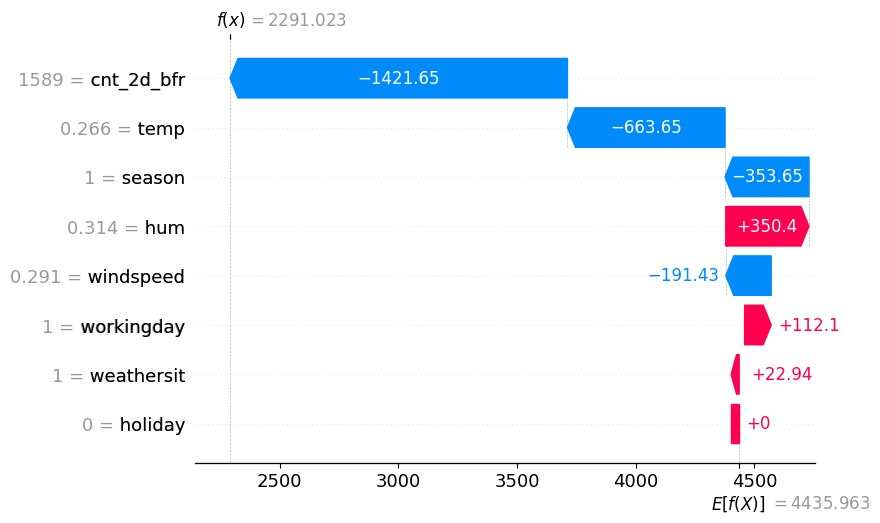

In [ ]:
import shap
import numpy as np


# pipeline including model and scaling
pipe = Pipeline([
    ("scaler", scaler),
    ("model", mods['svm'])
])

# pick instance
i = 0
x_instance = X_train.iloc[[i]]

# use a random small background sample (if you set it too large the algorithm will be very slow)
background = X_train.sample(100, random_state=42)

# create explainer using the pipeline
explainer = shap.Explainer(pipe.predict, background) #use shap.TreeExplainer() for tree models

# compute SHAP values
shap_values = explainer(x_instance)

# visualize
shap.plots.waterfall(shap_values[0])

For a tree model use TreeExplainer

We can also plot the mean absolute shapley values over all instances to get a global ranking of feature importance.

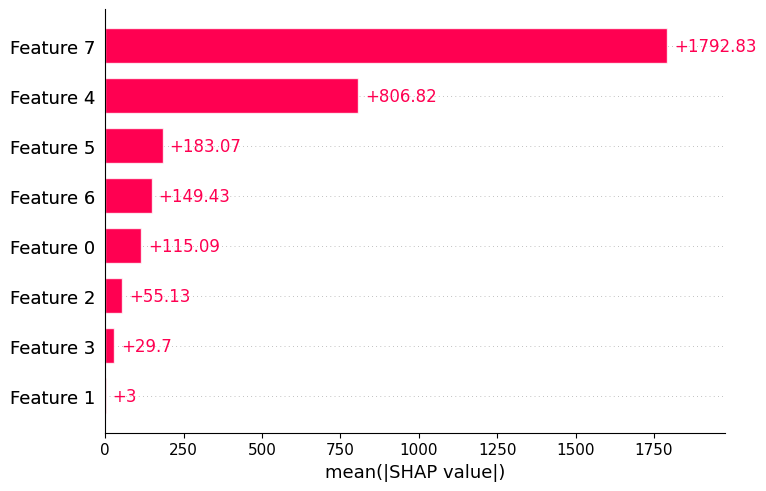

In [ ]:
shap.plots.bar(shap_values)

Decision plot, you see the shift in the prediction after adding each individual feature for a specific prediction.

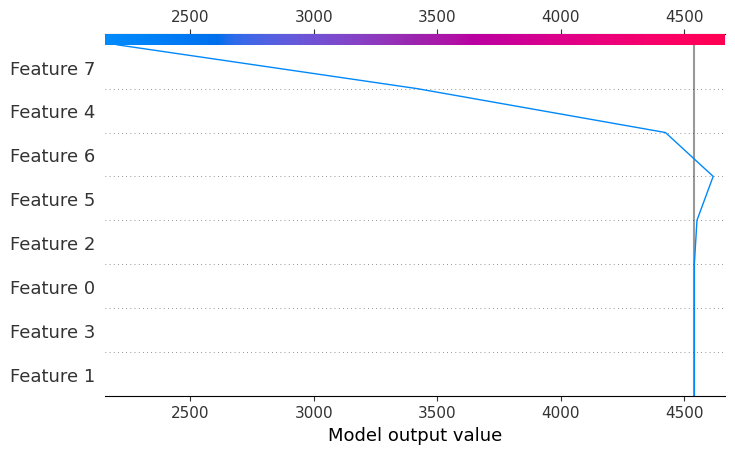

In [ ]:
shap.plots.decision(base_value=shap_values.base_values,shap_values=shap_values.values[:10])

# Resources

- https://shap.readthedocs.io/
- https://lime-ml.readthedocs.io/en/latest/
- 